In [41]:
import numpy as np
import matplotlib.pyplot as plt
import timeit

## NumPy

- Efficient and powerful library of arrays
- NumPy arrays are more efficient than Python lists as they are stored in a contiguous block of memory.
- Many functions are available for mathematical operations, linear algebra, and so on.

### Resources:

- Beginner: [Numpy official tutorial](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [Official Numpy Quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- [A visual guide to Numpy](https://jalammar.github.io/visual-numpy/)
- Somewhat advanced: [Nicolas P. Rougier's tutorial](https://github.com/rougier/numpy-tutorial?tab=readme-ov-file)
- [M Scott Shell's notes](https://sites.engineering.ucsb.edu/~shell/che210d/numpy.pdf)
- Harris, C. R. et al. Array Programming with NumPy. Nature 2020, 585 (7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2.



## A neat summary of core numpy methods

![](numpy.webp)


Source: Harris et al., Nature (2020). See above

### Defining arrays

In [42]:
# 1D python list
foo = [1, 2, 3, 4, 5]

# a use case: finding mean of a list of numbers
# using only python
sum=0
for i in foo:
    sum = sum+i
print(sum/5)

# using numpy
arr1 = np.array(foo)
# print(arr1,arr1[2])
print(f'Mean = {arr1.mean()}, sum = {arr1.sum()}')


3.0
Mean = 3.0, sum = 15


In [43]:
# 2D array
arr2 = np.array([[1, 2, 3], [4, 5, 6]])

print(arr2)
print(arr2[1,2])

[[1 2 3]
 [4 5 6]]
6


### Array attributes

In [44]:
print(arr2)
print(arr2.shape) #shape of the array
print(arr2.dtype)  # data type
print(arr2.size) # size of the array
print(arr2.ndim)  # number of dimensions

[[1 2 3]
 [4 5 6]]
(2, 3)
int64
6
2


In [45]:
# 2d arrays in python
a = []
for i in range(2):
    b = []
    for j in range(2):
        b.append(j)
    a.append(b)
print(a)

# numpy
a = np.tile(np.arange(2), (2, 1))
print(a)

[[0, 1], [0, 1]]
[[0 1]
 [0 1]]


### Initializing arrays

In [46]:
zeros_arr = np.zeros((4, 4))
zeros_arr

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [47]:
ones_arr = np.ones((2, 4))
ones_arr

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [48]:
full_arr = np.full((3,2), 'adsfljd')
full_arr

array([['adsfljd', 'adsfljd'],
       ['adsfljd', 'adsfljd'],
       ['adsfljd', 'adsfljd']], dtype='<U7')

In [49]:
identity_matrix = np.eye(3)
identity_matrix

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

(array([1031., 1054., 1009., 1023.,  981., 1002.,  969.,  969.,  992.,
         970.]),
 array([6.36604711e-05, 1.00049200e-01, 2.00034739e-01, 3.00020278e-01,
        4.00005817e-01, 4.99991356e-01, 5.99976895e-01, 6.99962434e-01,
        7.99947973e-01, 8.99933512e-01, 9.99919052e-01]),
 <BarContainer object of 10 artists>)

array([0.01442363, 0.15595053, 0.27229018, ..., 0.70038508, 0.11996656,
       0.20053322], shape=(10000,))

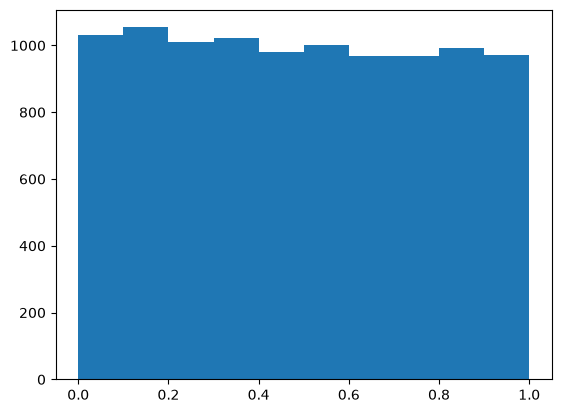

In [50]:
# Array with random values
# np.random.seed(4)
random_arr = np.random.random((10000))

plt.hist(random_arr)
random_arr

### Accessing elements

In [51]:
arr = np.array([10, 20, 30, 40, 50])

arr[0]  # first element
arr[-1]  # last element

np.int64(10)

np.int64(50)

In [52]:
# Slicing
arr[1:3]
arr[::2]  # Every second element
arr[:2]

array([20, 30])

array([10, 30, 50])

array([10, 20])

In [53]:
# Multi-dimensional arrays
arr2 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(arr2)
print(arr2[1, 2])
print(arr2[:, 2:]) # third column as a column vector
print(arr2[:, 2:].shape) # third column as a column vector

[[1 2 3]
 [4 5 6]
 [7 8 9]]
6
[[3]
 [6]
 [9]]
(3, 1)


## Boolean masking
Select elements using conditions.

In [54]:
x = np.array([1, -2, 3, -4])
print(x[x > 0])

[1 3]


## Aggregations with axis
Understand operations along dimensions.

In [55]:
arr = np.array([[1,2,3],[4,5,6]])
print(arr)
arr.mean(axis=0)
arr.mean(axis=1)

[[1 2 3]
 [4 5 6]]


array([2.5, 3.5, 4.5])

array([2., 5.])

## Views vs copies
Slicing usually returns a view.

In [56]:
a = np.array([1,2,3,4])
# b=a.copy()
b = a[1:3].copy()
id(a)
id(b)

print(b)
b[0] = 99
b
a

4878705232

4878704464

[2 3]


array([99,  3])

array([1, 2, 3, 4])

In [57]:
# a = [1,2,3,4]
# foo = []
# for i in a:
#     if i > 2:
#         # print(i)
#         foo.append(i)

# print(foo)

# numpy way
# print(list(range(5)))
a = np.array(range(5))
a
# b = a[:5] # b is a view
b = a[a>2] # b is a copy
b
b[0]=2 
b
a

array([0, 1, 2, 3, 4])

array([3, 4])

array([2, 4])

array([0, 1, 2, 3, 4])

### mathematical operations

In [58]:
arr = np.array([0, np.pi / 2, np.pi])

np.sin(arr)
np.cos(arr)
np.sqrt(arr)
import math
for i in arr:
    math.sqrt(i)

array([0.0000000e+00, 1.0000000e+00, 1.2246468e-16])

array([ 1.000000e+00,  6.123234e-17, -1.000000e+00])

array([0.        , 1.25331414, 1.77245385])

0.0

1.2533141373155001

1.7724538509055159

In [59]:
# element-wise Operations

arr1 = np.array([1, 2, 3])
arr2 = np.array([4, 5, 6])
print("Addition:", arr1 + arr2)
print("Multiplication:", arr1 * arr2)
np.dot(arr1,arr2)

Addition: [5 7 9]
Multiplication: [ 4 10 18]


np.int64(32)

In [60]:
# Broadcasting: operations on arrays of different shapes by expanding one array to match the shape of the other.

arr = np.array([1, 2, 3])
print("Adding 5 to each element:", arr + 5)

Adding 5 to each element: [6 7 8]


### Reshaping and Resizing

In [65]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
arr
# Reshape (2x3 to 3x2)
reshaped_arr = arr.reshape((1,6))
reshaped_arr

arr.resize((3, 2))  # Resize (modifies the array in place)
arr

array([[1, 2, 3],
       [4, 5, 6]])

array([[1, 2, 3, 4, 5, 6]])

array([[1, 2],
       [3, 4],
       [5, 6]])

### Aggregation Functions: to compute summaries of arrays

In [69]:
arr = np.array([10, 2, 3, 4, 5])
arr.sum()
arr.mean()
arr.std()
print(arr.min())
arr.max()
print(arr.argmin())

np.int64(24)

np.float64(4.8)

np.float64(2.785677655436824)

2


np.int64(10)

1


## Vectorization vs loops
NumPy is designed to avoid explicit Python loops.

In the following example:

- `np.sin(x)` operates on the entire array at once
- This internal loop runs in compiled C, not in Python, avoiding Python loop overhead
- much faster execution for large arrays


In [63]:
x = np.linspace(0, 2*np.pi, 50)
np.empty_like(x)
np.ones_like(x)


array([0.        , 0.12822827, 0.25645654, 0.38468481, 0.51291309,
       0.64114136, 0.76936963, 0.8975979 , 1.02582617, 1.15405444,
       1.28228272, 1.41051099, 1.53873926, 1.66696753, 1.7951958 ,
       1.92342407, 2.05165235, 2.17988062, 2.30810889, 2.43633716,
       2.56456543, 2.6927937 , 2.82102197, 2.94925025, 3.07747852,
       3.20570679, 3.33393506, 3.46216333, 3.5903916 , 3.71861988,
       3.84684815, 3.97507642, 4.10330469, 4.23153296, 4.35976123,
       4.48798951, 4.61621778, 4.74444605, 4.87267432, 5.00090259,
       5.12913086, 5.25735913, 5.38558741, 5.51381568, 5.64204395,
       5.77027222, 5.89850049, 6.02672876, 6.15495704, 6.28318531])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [64]:

x = np.linspace(0, 2*np.pi, 10000)

def loop_version(x):
    y = np.empty_like(x)
    for i in range(len(x)):
        y[i] = np.sin(x[i])
    return y

def vectorized_version(x):
    return np.sin(x)

# Run loop_version(x) `loop_num` times, measure the total execution time, and return that (in seconds)

loop_num = 10

print('Loop version')
t_loop = timeit.timeit(lambda: loop_version(x), number=loop_num)
t_vector = timeit.timeit(lambda: vectorized_version(x), number=loop_num)
print(f'Loop version took {t_loop:.6f} seconds, while the vectorized version took {t_vector:.6f} seconds, making it about {int(t_loop/t_vector)} times faster.')


Loop version
Loop version took 0.017060 seconds, while the vectorized version took 0.000555 seconds, making it about 30 times faster.
